# Daniel Rojo Mata
# Aprendizaje Automatizado, Tarea 2

# **PROBLEMA 3: Predicción de juegos**

Un club del juego de Go recopiló los resultados de varias partidas entre diferentes jugadores, almacenados en el archivo `partidas_entrenamiento.txt`, con el objetivo de predecir el resultado de partidas futuras, ejemplos de las cuales se encuentran en el archivo `partidas_prueba.txt`. Los archivos `partidas_entrenamiento.txt` y `partidas_prueba.txt` contienen 3 columnas: la primera
corresponde al identificador del jugador A, la segunda al identificador del jugador B y la tercera es el resultado de la partida (1 si ganó el jugador A o 0 si ganó el jugador B). En el club hay un total de D jugadores, por lo que cada identificador es un número entero entre 1 y D. La predicción del resultado de un juego se puede plantear como un problema de clasificación: dados 2 jugadores (A y
B) se requiere predecir si A ganó (y = 1) o si fue B (y = 0).

Realice los siguientes ejercicios:

**a)**.   Entrena y evalúa un clasificador bayesiano ingenuo. Al ser un modelo generativo (modela
la probabilidad conjunta $P (\mathbf{x}, y)$), es posible generar partidas artificiales con los parámetros calculados. Genera nuevas partidas que sigan la distribución modelada.

**b)**.   Entrena y evalúa un clasificador de regresión logística. Debido a que ambos atributos son categóricos, es necesario cambiar la codificación. Explica el procedimiento y la lógica de la codificación que realizaste. Visualiza los valores de los parámetros del modelo de regresión logística y discute qué interpretación tendrían de acuerdo a la codificación realizada. Grafica las curvas ROC y de precisión-exhaustividad y reporta sus áreas bajo la curva.

**c)**. Compara el clasificador bayesiano ingenuo y regresión logística en este problema. ¿Qué ventajas y desventajas tienen los modelos entrenados? ¿Qué pasaría si se entrena el clasificador bayesiano ingenuo con los vectores recodificados o si se entrena un modelo de regresión logística usando los vectores de entrada originales? ¿Consideras que las presuposiciones de cada clasificador son apropiadas para los datos del problema? ¿Para este tipo de problemas cuál de los dos recomendarías y por qué?

**d)**. Deriva la regla de actualización para el algoritmo del descenso por gradiente de un clasificador donde $\hat{y} = sigm(\theta^\top \mathbf{x})$ y la función de pérdida sea
$$
E(\theta) = \frac{1}{2} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2.
$$
Discute las diferencias entre este clasificador y el de regresión logística y el efecto que tendría en el comportamiento del algoritmo del descenso por gradiente cambiar la función de pérdida por
$$
E(\theta) = \frac{1}{2n} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2.
$$

# Librerías a usar

In [10]:
# === Manejo de datos y visualización ===
import pandas as pd              # Para manipulación de datos con DataFrames
import numpy as np               # Para operaciones numéricas y creación de matrices
import matplotlib.pyplot as plt  # Para generación de gráficos
import seaborn as sns

# === Preprocesamiento ===
from sklearn.preprocessing import LabelEncoder  # Codificación de variables categóricas (IDs de jugadores)

# === Modelos de clasificación ===
from sklearn.naive_bayes import CategoricalNB       # Clasificador Bayesiano para variables categóricas
from sklearn.linear_model import LogisticRegression # Modelo de regresión logística

# === Métricas y evaluación de modelos ===
from sklearn.metrics import (
    accuracy_score,              # Precisión del modelo
    confusion_matrix,            # Matriz de confusión
    ConfusionMatrixDisplay,      # Visualización de la matriz de confusión
    roc_curve,                   # Puntos para la curva ROC
    roc_auc_score,               # Área bajo la curva ROC
    precision_recall_curve,      # Curva precisión-exhaustividad
    average_precision_score      # Área promedio bajo la curva precisión-recall
)

# Se importa la data

In [2]:
# Archivos con los que se trabajará
# Favor de tener los archivos en la misma carpeta en donde se encuentra este documento
entrenamiento = "partidas_entrenamiento.csv"
prueba = "partidas_prueba.csv"

# Se leen los archivos con pandas
data_entrenamiento = pd.read_csv(entrenamiento)
data_prueba = pd.read_csv(prueba)

# **SOLUCIÓN INCISO a)**

## Codificación de los identificadores de jugadores

Los modelos de aprendizaje automático no trabajan directamente con variables categóricas representadas como texto o números arbitrarios, ya que podrían interpretar valores numéricos como si tuvieran un orden o una distancia significativa (lo cual no aplica en este caso).

Aunque los identificadores de los jugadores (`id_blancas` e `id_negras`) son números, **no representan cantidades ni tienen un orden lógico**, por lo que deben tratarse como categorías.

En esta celda se utiliza `LabelEncoder` para transformar cada identificador de jugador a un valor numérico entero único, de forma consistente en todos los datos. Es decir, un mismo jugador tendrá el mismo valor codificado sin importar si aparece en los datos de entrenamiento o de prueba, y sin importar si juega como blancas o negras.

Esta codificación es necesaria para entrenar modelos como el clasificador Bayesiano Ingenuo con `CategoricalNB`, que espera valores enteros representando categorías.

In [3]:
# Creamos una instancia del codificador
encoder = LabelEncoder()

# Ajustamos el codificador con todos los IDs posibles (jugadores que aparecen como blancas o negras en entrenamiento y prueba)
# Esto asegura que el mapeo sea consistente en todos los datos
encoder.fit(pd.concat([
    data_entrenamiento['id_blancas'], 
    data_entrenamiento['id_negras'], 
    data_prueba['id_blancas'], 
    data_prueba['id_negras']
]))

# Transformamos los IDs de las columnas 'id_blancas' y 'id_negras' en el conjunto de entrenamiento
# y los almacenamos como nuevas columnas 'W' (de white) y 'B' (de Black)
data_entrenamiento['W'] = encoder.transform(data_entrenamiento['id_blancas'])
data_entrenamiento['B'] = encoder.transform(data_entrenamiento['id_negras'])

# Hacemos lo mismo para el conjunto de prueba
data_prueba['W'] = encoder.transform(data_prueba['id_blancas'])
data_prueba['B'] = encoder.transform(data_prueba['id_negras'])

# Bayes Ingenuo

En esta celda se entrena un **clasificador Bayesiano Ingenuo** (`CategoricalNB`) utilizando como entrada las columnas `W` y `B`, que representan los identificadores codificados de los jugadores (blancas y negras, respectivamente).

Este clasificador asume que las características de entrada son **variables categóricas independientes**, y estima la probabilidad de cada clase (`ganador = 0` o `1`) a partir de las frecuencias observadas en los datos.

<!-- ### Flujo del bloque:

- Se definen los conjuntos de entrenamiento (`X_train`, `y_train`) y prueba (`X_test`, `y_test`).
- Se crea una instancia del modelo `CategoricalNB` para trabajar con datos categóricos.
- Se entrena el modelo usando `.fit()` con los datos de entrenamiento.
- Se realizan predicciones sobre los datos de prueba con `.predict()`.
- Se evalúa el rendimiento del modelo utilizando la **precisión** (`accuracy_score`), que indica el porcentaje de partidas correctamente clasificadas.

Este modelo es adecuado en este caso porque trabaja directamente con variables categóricas codificadas como enteros y proporciona una forma sencilla e interpretable de modelar probabilidades condicionales. -->

In [4]:
# Definimos las variables de entrada y salida para entrenamiento
X_train = data_entrenamiento[['W', 'B']]
y_train = data_entrenamiento['ganador']

# Definimos las variables de entrada y salida para prueba
X_test = data_prueba[['W', 'B']]
y_test = data_prueba['ganador']

# Creamos una instancia del clasificador Bayesiano Ingenuo para variables categóricas
naive_bayes = CategoricalNB()

# Entrenamos el modelo con los datos de entrenamiento
naive_bayes.fit(X_train, y_train)

# Realizamos predicciones sobre el conjunto de prueba
y_pred = naive_bayes.predict(X_test)

# Calculamos la precisión del modelo
acc = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {acc:.3f}")

Precisión del modelo: 0.696


## Visualización de los resultados

### Histograma

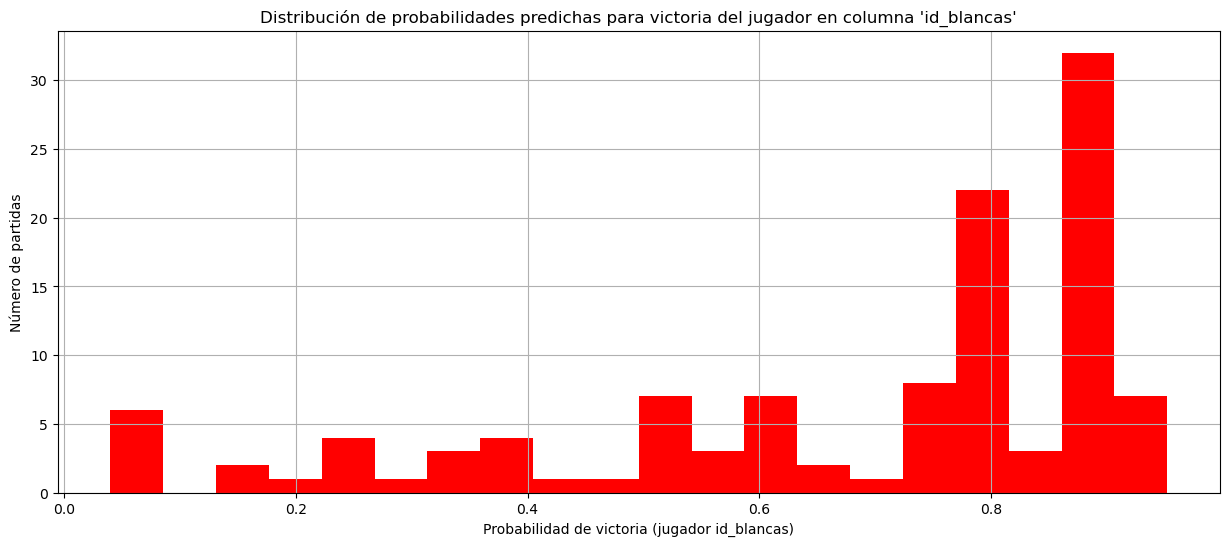

In [6]:
# Visualización de la distribución de probabilidades predichas por el modelo

# Obtenemos las probabilidades predichas para el conjunto de prueba
probs = naive_bayes.predict_proba(X_test)

# Graficamos un histograma con las probabilidades de que gane el jugador que aparece como 'id_blancas'
plt.figure(figsize=(15, 6))  # Aumenta el tamaño de la figura
plt.hist(probs[:, 1], bins=20, color="red")
plt.title("Distribución de probabilidades predichas para victoria del jugador en columna 'id_blancas'")
plt.xlabel("Probabilidad de victoria (jugador id_blancas)")
plt.ylabel("Número de partidas")
plt.grid(True)
plt.show()

### Matriz de confusión

En esta celda se muestra la **matriz de confusión** del clasificador Bayesiano Ingenuo aplicado al conjunto de prueba.

Se utilizaron nombres de variables y etiquetas más descriptivos para facilitar la comprensión del resultado:

- `"Gana jugador id_blancas"`: indica que ganó el jugador que aparece como `id_blancas` en la partida.
- `"Gana jugador id_negras"`: indica que ganó el jugador que aparece como `id_negras`.

La matriz muestra:
- En las **filas**, los resultados reales de las partidas.
- En las **columnas**, las predicciones hechas por el modelo.

La diagonal principal representa las predicciones correctas, mientras que los valores fuera de la diagonal son errores del modelo. Esta visualización permite detectar posibles sesgos o dificultades del modelo para distinguir correctamente entre los dos jugadores.

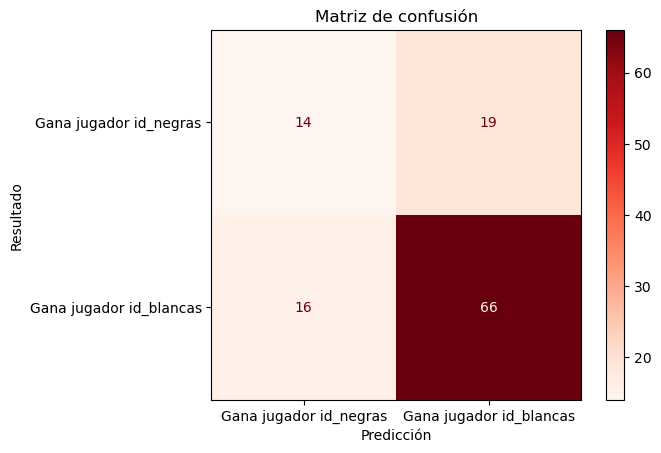

In [7]:
# Matriz de confusión para el clasificador Bayesiano Ingenuo

# Calculamos la matriz de confusión comparando etiquetas verdaderas con predichas
matriz_confusion = confusion_matrix(y_test, y_pred)

# Creamos el objeto de visualización con etiquetas claras
visualizacion_confusion = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=["Gana jugador id_negras", "Gana jugador id_blancas"]
)

# Mostramos la matriz con un estilo visual amigable
visualizacion_confusion.plot(cmap="Reds")

# Añadimos título y etiquetas de ejes
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Resultado")
plt.show()

### Análisis de la matriz de confusión

La siguiente matriz de confusión representa el desempeño del **clasificador Bayesiano Ingenuo** al predecir el resultado de las partidas:

|                          | **Predicción: Gana jugador `id_negras`** | **Predicción: Gana jugador `id_blancas`** |
|--------------------------|------------------------------------------|-------------------------------------------|
| **Resultado real: Gana `id_negras`** | 14                                       | 19                                        |
| **Resultado real: Gana `id_blancas`** | 16                                       | 66                                        |

### Interpretación:

- **Verdaderos positivos (VP): 66**  
  El modelo predijo "gana `id_blancas`" y acertó.

- **Verdaderos negativos (VN): 14**  
  El modelo predijo "gana `id_negras`" y acertó.

- **Falsos positivos (FP): 19**  
  El modelo predijo "gana `id_blancas`" pero ganó `id_negras`.

- **Falsos negativos (FN): 16**  
  El modelo predijo "gana `id_negras`" pero ganó `id_blancas`.

### Métricas rápidas:

- **Precisión total**:  
  $$
  \frac{66 + 14}{115} \approx 69.6\%
  $$

- **Precisión por clase**:  
  - Gana `id_blancas`: $ \frac{66}{66 + 16} = 80.5\% $
  - Gana `id_negras`: $ \frac{14}{14 + 19} = 42.4\% $

### Agunas observaciones:

- El modelo **predice mejor cuando gana el jugador en `id_blancas`**.
- Tiene dificultades para detectar victorias del jugador en `id_negras`, lo que puede indicar un **sesgo hacia predecir que gana `id_blancas`**.

# Partidas Artificiales

En esta celda se generan **partidas ficticias** utilizando el modelo Bayesiano Ingenuo previamente entrenado. El objetivo es aprovechar que este modelo es de tipo **generativo**, es decir, puede modelar la distribución conjunta de los datos y, por lo tanto, puede usarse para simular nuevos ejemplos.

### ¿Qué se hace aquí?

1. **Se calcula la distribución empírica** de aparición de los jugadores en las posiciones de blancas (`W`) y negras (`B`) usando los datos de entrenamiento.
   - Esto permite muestrear jugadores respetando cómo de común es que cada uno juegue.

2. **Se generan combinaciones de jugadores**:
   - Se generan 500 pares aleatorios `(jugador_blancas, jugador_negras)` usando las distribuciones anteriores.

3. **Se predice el resultado de cada partida generada**:
   - Se utiliza el modelo `naive_bayes.predict(...)` para predecir quién ganaría en cada enfrentamiento simulado.

4. **Se revierte la codificación de los identificadores**:
   - Se convierten los identificadores codificados (números) de vuelta a sus valores originales usando `encoder.inverse_transform(...)`.

5. **Se muestra un ejemplo de las partidas artificiales generadas**, incluyendo:
   - `id_blancas`
   - `id_negras`
   - `ganador` (1 si ganó `id_blancas`, 0 si ganó `id_negras`)

Este procedimiento permite **simular partidas realistas** de acuerdo con la distribución aprendida por el modelo, lo cual es útil para análisis, visualización o generación de datos sintéticos.


In [8]:
# Se obtiene la distribución empírica de aparición de jugadores en cada posición
# Cuántas veces aparece cada jugador como blancas ('W') y como negras ('B')
# Recordar: W (white) para blancas, B (black) para negras
distribucion_blancas = data_entrenamiento['W'].value_counts(normalize=True).sort_index()
distribucion_negras = data_entrenamiento['B'].value_counts(normalize=True).sort_index()

# Se definen cuántas partidas se van a generar artificialmente
numero_partidas = 500  # Número total de partidas sintéticas a simular

# Se generan jugadores para la posición de blancas ('W')
# Usando muestreo aleatorio según su frecuencia en el conjunto de entrenamiento
jugadores_blancas_generados = np.random.choice(
    distribucion_blancas.index, 
    size=numero_partidas, 
    p=distribucion_blancas.values
)

# Se generan jugadores para la posición de negras ('B') de la misma manera
jugadores_negras_generados = np.random.choice(
    distribucion_negras.index, 
    size=numero_partidas, 
    p=distribucion_negras.values
)

# Se construye un DataFrame con las combinaciones generadas (codificadas)
# Cada fila representa una partida artificial con jugadores en W y B
partidas_generadas_codificadas = pd.DataFrame({
    'W': jugadores_blancas_generados, 
    'B': jugadores_negras_generados
})

# Se predicen los resultados (ganador: 0 o 1) usando el modelo Naive Bayes ya entrenado
resultados_generados = naive_bayes.predict(partidas_generadas_codificadas)

# Se agregan al DataFrame los identificadores originales de los jugadores
# Esto se logra revirtiendo la codificación usando el encoder original
partidas_generadas_codificadas['id_blancas'] = encoder.inverse_transform(partidas_generadas_codificadas['W'])
partidas_generadas_codificadas['id_negras'] = encoder.inverse_transform(partidas_generadas_codificadas['B'])

# Se asigna la predicción del ganador a una nueva columna
partidas_generadas_codificadas['ganador'] = resultados_generados

# Se eliminan las columnas codificadas ('W' y 'B') para dejar el DataFrame limpio
partidas_generadas = partidas_generadas_codificadas.drop(columns=['W', 'B'])

# Se imprimen las primeras 10 partidas generadas artificialmente para inspección
print("Partidas artificiales generadas:")
partidas_generadas.head(10)

Partidas artificiales generadas:


,id_blancas,id_negras,ganador
0,36,35,0
1,119,12,1
2,18,112,0
3,35,60,1
4,4,35,0
5,18,110,0
6,105,89,1
7,38,47,0
8,124,122,0
9,121,13,0


### Distribución de ganadores con datos artificiales

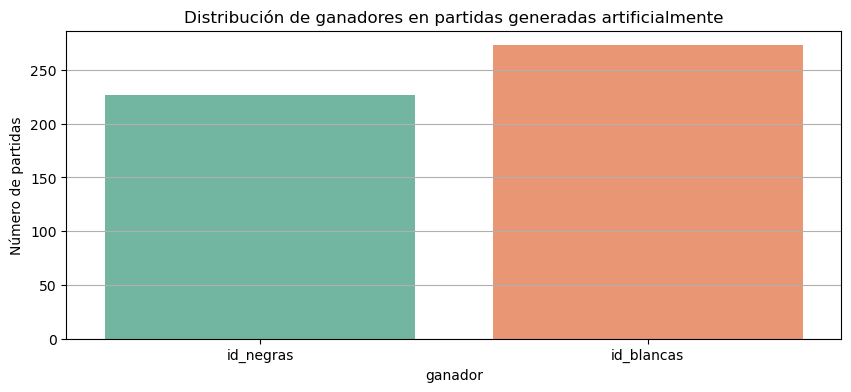

In [11]:
# Preparamos los datos como DataFrame para usar hue correctamente
conteo_df = pd.DataFrame({
    "ganador": ["id_negras", "id_blancas"],
    "conteo": partidas_generadas['ganador'].value_counts().sort_index().values
})

plt.figure(figsize=(10, 4))
sns.barplot(data=conteo_df, x="ganador", y="conteo", palette="Set2", hue="ganador", legend=False)
plt.title("Distribución de ganadores en partidas generadas artificialmente")
plt.ylabel("Número de partidas")
plt.grid(axis='y')
plt.show()

# **SOLUCIÓN INCISO b)**

## Codificación de datos para regresión logística

En esta celda se realiza la **codificación de los datos de entrada** para entrenar un modelo de **regresión logística**, considerando que los identificadores de los jugadores son 
**categóricos**.

### Objetivo de esta codificación:

Representar cada partida como un vector de longitud `D` (número total de jugadores).  
- Cada posición del vector corresponde a un jugador.
- Si un jugador aparece en una partida:
  - Se asigna **`+1`** si juega como blancas (`id_blancas`)
  - Se asigna **`-1`** si juega como negras (`id_negras`)
  - Los jugadores que no participan en esa partida tienen un **0**

Este tipo de codificación permite que el modelo de regresión logística **aprenda un peso para cada jugador**, el cual representa su "habilidad relativa". Si un jugador tiene un coeficiente positivo, eso sugiere que **aumenta la probabilidad de victoria cuando juega como blancas**; un coeficiente negativo implicaría lo contrario.

<!-- ### Resumen de pasos:

- Se calcula el número total de jugadores `D` a partir de todos los datos.
- Se define la función `codificar_partidas(...)` que convierte cada partida en un vector de tamaño `D`.
- Se aplica esta función para construir `X_train` y `X_test`.
- Se extraen las etiquetas `y_train` y `y_test` correspondientes a los resultados de las partidas (1 si gana blancas, 0 si gana negras).

Esta representación es esencial para entrenar un modelo lineal que pueda aprender a predecir el resultado de una partida en función de los jugadores que participan. -->

In [13]:
# Se obtiene el número total de jugadores únicos en todos los datos
numero_jugadores = max(
    data_entrenamiento[['id_blancas', 'id_negras']].max().max(),
    data_prueba[['id_blancas', 'id_negras']].max().max()
)

def codificar_partidas(data, D):
    """
    Codifica cada partida como un vector de dimensión D, donde D es el número total de jugadores.

    La codificación asigna:
    - +1 en la posición correspondiente al jugador que juega como blancas (id_blancas)
    - -1 en la posición correspondiente al jugador que juega como negras (id_negras)
    - 0 en las demás posiciones (jugadores que no participan en la partida)

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame que contiene las columnas 'id_blancas' y 'id_negras' para cada partida.

    D : int
        Número total de jugadores (dimensión del vector codificado).

    Returns
    -------
    numpy.ndarray
        Matriz de codificación de tamaño (n_partidas, D), donde cada fila representa una partida.
    """
    X = np.zeros((len(data), D))
    for i, (jugador_blancas, jugador_negras) in enumerate(zip(data['id_blancas'], data['id_negras'])):
        X[i, jugador_blancas - 1] = 1   # jugador que juega como blancas (positivo)
        X[i, jugador_negras - 1] = -1  # jugador que juega como negras (negativo)
    return X

# Se generan las matrices codificadas para entrenamiento y prueba
X_train = codificar_partidas(data_entrenamiento, numero_jugadores)
X_test = codificar_partidas(data_prueba, numero_jugadores)

# Las etiquetas de salida (ganador: 1 si gana blancas, 0 si gana negras)
y_train = data_entrenamiento['ganador'].values
y_test = data_prueba['ganador'].values

### ¿Qué hace este modelo?

La regresión logística aprende una combinación lineal de los atributos de entrada (jugadores codificados) para estimar la probabilidad de que el resultado de la partida sea 1 (es decir, que gane el jugador en `id_blancas`).

Cada coeficiente aprendido por el modelo puede interpretarse como una medida de la **influencia relativa de un jugador en el resultado**.

<!-- ### Flujo del bloque:

- Se crea el modelo con `LogisticRegression`, usando el solver `'liblinear'` (eficiente en conjuntos pequeños).
- Se entrena con los datos de entrenamiento.
- Se evalúa el rendimiento del modelo sobre el conjunto de prueba mediante **precisión**, es decir, el porcentaje de partidas correctamente clasificadas. -->

In [18]:
# Se crea el modelo de regresión logística
modelo_logistico = LogisticRegression(solver='liblinear')  # Solver recomendado para datasets pequeños o medianos

# Se entrena el modelo con los datos codificados
modelo_logistico.fit(X_train, y_train)

# Se evalúa el modelo sobre el conjunto de prueba
precision_logistico = modelo_logistico.score(X_test, y_test)
print(f"Precisión del modelo de regresión logística: {precision_logistico:.3f}")

Precisión del modelo de regresión logística: 0.704


## Visualización de los resultados

### Histograma

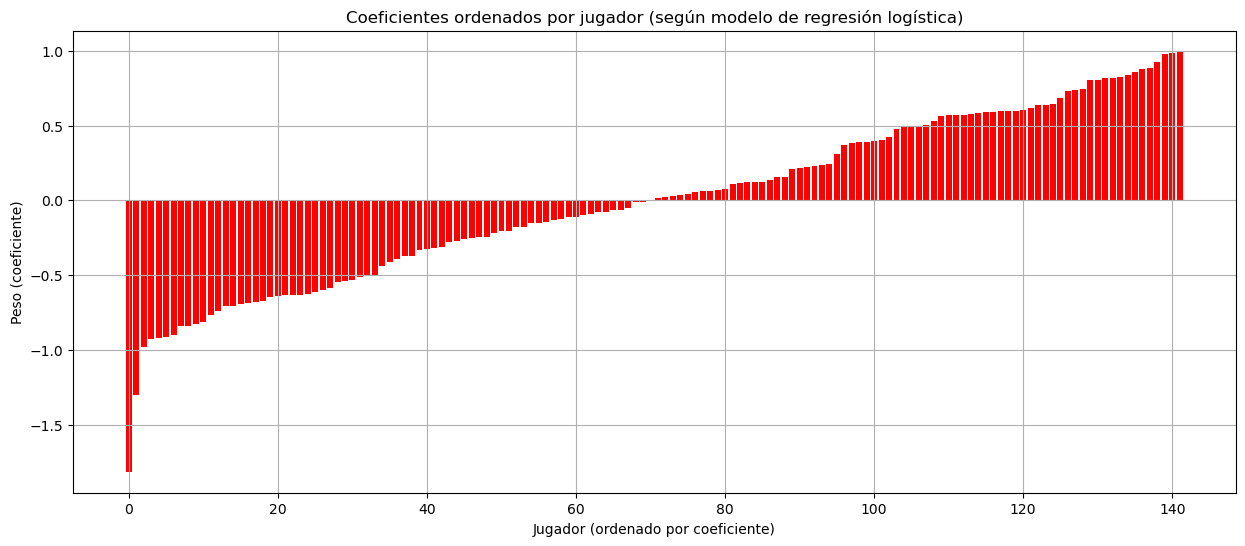

In [19]:
# Obtener los coeficientes aprendidos por el modelo
coeficientes = modelo_logistico.coef_[0]

# Ordenar los coeficientes de menor a mayor
indices_ordenados = np.argsort(coeficientes)

# Visualizar los coeficientes ordenados
plt.figure(figsize=(15, 6))
plt.bar(range(numero_jugadores), coeficientes[indices_ordenados], color="red")
plt.title("Coeficientes ordenados por jugador (según modelo de regresión logística)")
plt.ylabel("Peso (coeficiente)")
plt.xlabel("Jugador (ordenado por coeficiente)")
plt.grid(True)
plt.show()

### Otro histograma

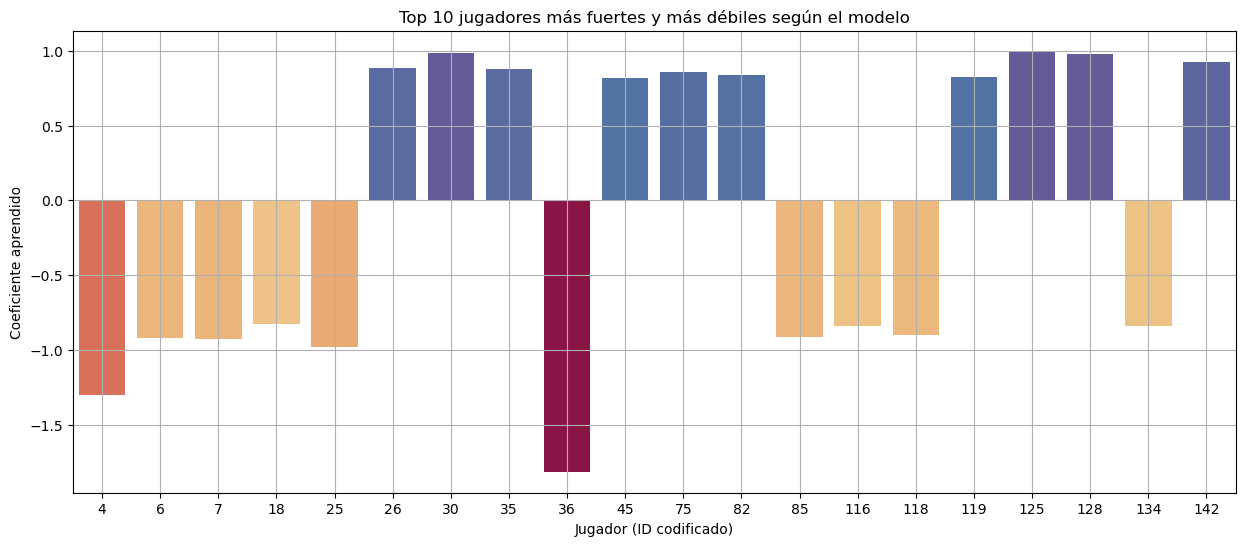

In [24]:
# Extraer los coeficientes del modelo ya entrenado
coeficientes = modelo_logistico.coef_[0]

# Crear un DataFrame auxiliar con los jugadores codificados y sus coeficientes
df_coeficientes = pd.DataFrame({
    'jugador_codificado': range(1, numero_jugadores + 1),
    'coeficiente': coeficientes
})

# Seleccionar los 10 jugadores con coeficientes más altos y más bajos
top_jugadores = pd.concat([
    df_coeficientes.nlargest(10, 'coeficiente'),
    df_coeficientes.nsmallest(10, 'coeficiente')
])

# Crear una columna ficticia para usar como 'hue' y poder aplicar el palette sin warning
top_jugadores['hue'] = top_jugadores['coeficiente']

# Visualización
plt.figure(figsize=(15, 6))
sns.barplot(
    data=top_jugadores, 
    x='jugador_codificado', 
    y='coeficiente', 
    hue='hue',                # Esto activa el uso del palette
    palette='Spectral', 
    legend=False              # Ocultamos la leyenda innecesaria
)
plt.title("Top 10 jugadores más fuertes y más débiles según el modelo")
plt.xlabel("Jugador (ID codificado)")
plt.ylabel("Coeficiente aprendido")
plt.grid(True)
plt.show()

### Matriz de confusión

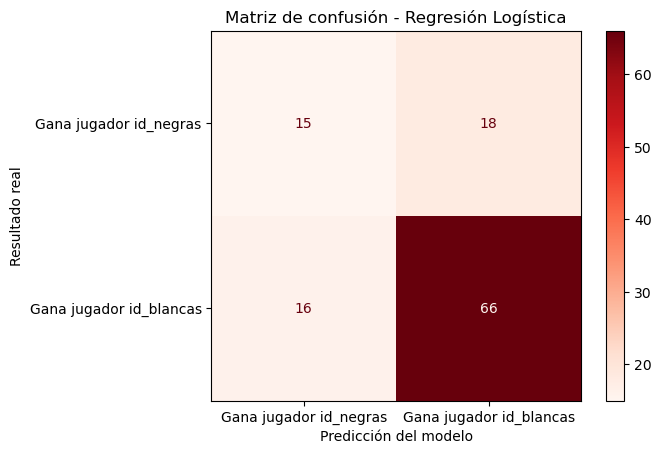

In [25]:
# Matriz de confusión para el modelo de regresión logística
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones sobre el conjunto de prueba
y_pred_logistico = modelo_logistico.predict(X_test)

# Cálculo de la matriz de confusión
matriz_confusion_logistico = confusion_matrix(y_test, y_pred_logistico)

# Visualización con etiquetas claras
disp_logistico = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_logistico,
    display_labels=["Gana jugador id_negras", "Gana jugador id_blancas"]
)

# Mostrar la matriz con un mapa de color azul
disp_logistico.plot(cmap="Reds")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción del modelo")
plt.ylabel("Resultado real")
plt.show()

### Análisis de la matriz de confusión - Regresión Logística

La siguiente matriz de confusión corresponde al rendimiento del modelo de **regresión logística** en el conjunto de prueba. Este modelo fue entrenado con una codificación vectorial que asigna `+1` al jugador que juega como blancas y `-1` al jugador que juega como negras.

|                          | **Predicción: Gana jugador `id_negras`** | **Predicción: Gana jugador `id_blancas`** |
|--------------------------|------------------------------------------|-------------------------------------------|
| **Resultado real: Gana `id_negras`** | 15                                       | 18                                        |
| **Resultado real: Gana `id_blancas`** | 16                                       | 66                                        |

### Interpretación:

- **Verdaderos positivos (VP = 66)**: El modelo predijo "gana jugador `id_blancas`" y acertó.
- **Verdaderos negativos (VN = 15)**: El modelo predijo "gana jugador `id_negras`" y acertó.
- **Falsos positivos (FP = 18)**: El modelo predijo "gana `id_blancas`", pero ganó `id_negras`.
- **Falsos negativos (FN = 16)**: El modelo predijo "gana `id_negras`", pero ganó `id_blancas`.

### Métricas rápidas:

- **Precisión total**:  
  $$
  \frac{66 + 15}{115} \approx 70.4\%
  $$

- **Precisión por clase**:  
  - Gana `id_blancas`: $ \frac{66}{66 + 16} = 80.5\% $  
  - Gana `id_negras`: $ \frac{15}{15 + 18} = 45.5\% $

### Algunas observaciones:

- Al igual que el clasificador Bayesiano Ingenuo, la regresión logística tiene mejor rendimiento prediciendo cuando gana el jugador en `id_blancas`.
- El número de errores sigue siendo mayor cuando gana `id_negras`, aunque ligeramente menor en comparación con el modelo anterior.
- La precisión general mejora un poco (de 69.6% a 70.4%), lo que sugiere que la codificación y el modelo lineal logran capturar mejor los patrones.

Esta matriz es útil para evaluar si el modelo presenta **sesgos hacia una clase** y entender mejor cómo se comporta con distintos tipos de partidas.


## Curvas

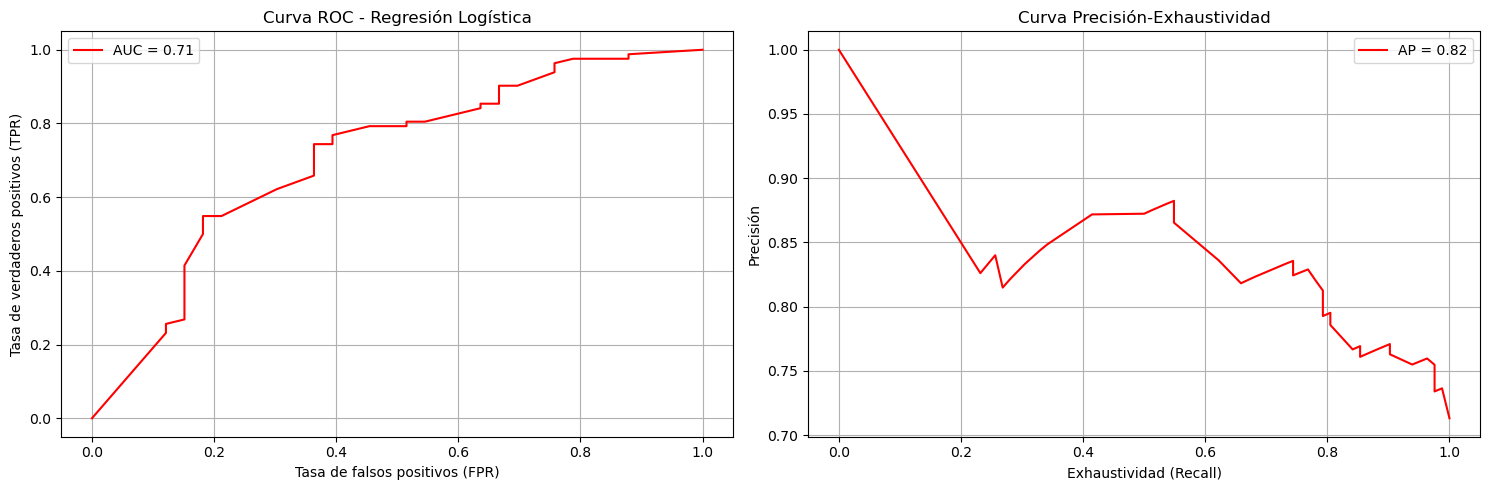

In [26]:
# Probabilidades estimadas para la clase positiva (gana jugador id_blancas)
y_scores_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

# Cálculo curva ROC
fpr_logistico, tpr_logistico, _ = roc_curve(y_test, y_scores_logistico)
roc_auc_logistico = roc_auc_score(y_test, y_scores_logistico)

# Cálculo curva Precisión-Exhaustividad
precision_logistico, recall_logistico, _ = precision_recall_curve(y_test, y_scores_logistico)
ap_logistico = average_precision_score(y_test, y_scores_logistico)

# Crear figura con dos subgráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Curva ROC
axes[0].plot(fpr_logistico, tpr_logistico, label=f"AUC = {roc_auc_logistico:.2f}", color="r")
axes[0].set_xlabel("Tasa de falsos positivos (FPR)")
axes[0].set_ylabel("Tasa de verdaderos positivos (TPR)")
axes[0].set_title("Curva ROC - Regresión Logística")
axes[0].legend()
axes[0].grid(True)

# Curva Precisión-Exhaustividad
axes[1].plot(recall_logistico, precision_logistico, label=f"AP = {ap_logistico:.2f}", color="r")
axes[1].set_xlabel("Exhaustividad (Recall)")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva Precisión-Exhaustividad")
axes[1].legend()
axes[1].grid(True)

# Mostrar ambas gráficas
plt.tight_layout()
plt.show()

# **SOLUCIÓN c)**

### ¿Qué ventajas y desventajas tienen los modelos entrenados?

#### Naive Bayes  
Este modelo es de tipo generativo, lo que implica que aprende la distribución conjunta $P(x, y) = P(x \mid y) \cdot P(y)$, es decir, cómo se comportan los datos dentro de cada clase. Posteriormente, utiliza la regla de Bayes para estimar la probabilidad de pertenecer a una clase específica.

**Ventajas**
- Funciona razonablemente bien incluso si la hipótesis de independencia entre variables no se cumple completamente.  
- Permite generar datos nuevos al modelar la distribución por clase.  
- Es sencillo de implementar, rápido de entrenar y eficaz incluso con poca información o datos ruidosos.  

**Desventajas**
- Las probabilidades predichas pueden no reflejar bien la realidad, dando una falsa sensación de certeza.  
- Las acciones de un jugador afectan a otro, lo que rompe la suposición de independencia entre variables.  
---

#### Regresión Logística  
Este modelo estima directamente la probabilidad condicional $P(y \mid x)$, concentrándose en distinguir correctamente entre clases sin modelar sus distribuciones individuales.

**Ventajas**
- Ofrece probabilidades que suelen reflejar con precisión la certeza del modelo.  
- Con una cantidad suficiente de datos, puede superar a los modelos generativos en desempeño.  
- Los coeficientes resultantes permiten analizar el impacto de cada jugador en el resultado.  

**Desventajas**
- No se puede utilizar para crear ejemplos nuevos.  
- Es necesario transformar las variables categóricas a representaciones numéricas.  
- Si las entradas no se procesan adecuadamente, el modelo puede no aprovechar toda la información disponible.

---

### ¿Qué pasa si se entrena Naive Bayes con vectores recodificados?

Al utilizar vectores que codifican jugadores, el modelo tiene dificultades debido a su hipótesis de independencia, ya que los jugadores están relacionados al enfrentarse entre sí. Sin embargo, los resultados pueden seguir siendo razonables.

---

### ¿Y si se entrena regresión logística con los IDs originales?

Los identificadores numéricos pueden inducir un orden que no representa la realidad (por ejemplo, un ID más alto no implica mejor rendimiento). Esto puede provocar predicciones erróneas o difíciles de interpretar para el modelo.

---

### ¿Las suposiciones de cada modelo se ajustan a los datos?

- **Regresión Logística:** Se ajusta mejor, especialmente si se realiza una codificación adecuada, ya que modela bien la relación entre variables y el resultado.
- **Naive Bayes:** No completamente, ya que parte de una independencia que no siempre se cumple, aunque en la práctica puede ofrecer buenos resultados.  

---

### ¿Cuál se recomienda y por qué?

Aunque los dos modelos pueden tener un desempeño similar, Naive Bayes puede ser útil si se desea simular partidas generadas artificialmente pero la *Regresión Logística* suele ser más adecuada, ya que se ajusta mejor a los datos, permite interpretar el efecto de cada jugador y generalmente ofrece buen resultado. 


# **SOLUCIÓN d)**

Sea la expresión 

$$
E(\theta) = \frac{1}{2} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2,
$$

donde $\hat{y}^{(i)} = \sigma(z)$ y $z = \theta^T x^{(i)}$.

Luego, recuérdese que por la regla de la cadena se tiene:

$$
\frac{\partial E}{\partial \theta} = \frac{\partial E}{\partial \hat{y}} \cdot \frac{d \hat{y}}{d z} \cdot \frac{\partial z}{\partial \theta}
$$

De donde, por notación, $\frac{d}{d(\cdot)}$ denota derivada respecto a la variable correspondiente, por lo que:

$$
\frac{\partial E}{\partial \hat{y}} = \frac{\partial}{\partial \hat{y}} \left( \frac{1}{2} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2 \right)
= \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)
$$

$$
\frac{d \hat{y}}{d z} = \frac{d}{dz} \left( \sigma(z) \right) = \frac{d}{dz} \left( \frac{1}{1 + e^{-z}} \right) 
= \frac{(0)(1 + e^{-z}) - (1)(-e^{-z})}{(1 + e^{-z})^2} 
= \frac{e^{-z}}{(1 + e^{-z})^2}
$$

$$
= \frac{1}{1 + e^{-z}} \cdot \frac{e^{-z}}{1 + e^{-z}} 
= \sigma(z) \cdot (1 - \sigma(z)) 
= \hat{y}^{(i)} \cdot (1 - \hat{y}^{(i)})
$$

$$
\frac{\partial z}{\partial \theta} = \frac{\partial}{\partial \theta} \left( \theta^T x^{(i)} \right) = x^{(i)}
$$

Por lo tanto,

$$
\frac{\partial E}{\partial \theta} = \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right) \cdot \hat{y}^{(i)} \cdot (1 - \hat{y}^{(i)}) \cdot x^{(i)} = \nabla_\theta E(\theta)
$$

De esta manera se puede hacer la regla de actualización del gradiente de la siguiente forma:

$$
\theta \leftarrow \theta - \eta \nabla_\theta E(\theta) 
= \theta - \eta \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right) \cdot \hat{y}^{(i)} \cdot (1 - \hat{y}^{(i)}) \cdot x^{(i)}
$$

Si se cambiara la regla a 

$$
E(\theta) = \frac{1}{2n} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2,
$$ 

la regla de actualización del gradiente se haría:

$$
\theta \leftarrow \theta - \eta \cdot \frac{1}{n} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right) \cdot \hat{y}^{(i)} \cdot (1 - \hat{y}^{(i)}) \cdot x^{(i)}
$$


---

### Ventajas y desventajas de usar MSE con activación sigmoide

- Aunque el MSE es intuitivo y fácil de derivar, **no es ideal para clasificación binaria**. Esto se debe a que:

  - Su derivada se aplana cuando $\hat{y}$ se aleja de $y$, lo cual **reduce la magnitud del gradiente**, y puede hacer que el descenso por gradiente sea **muy lento**.
  - No penaliza lo suficiente cuando las predicciones están mal **pero con alta confianza** (ej. $\hat{y} = 0.95$ cuando $y = 0$).

- Por el contrario, la **entropía cruzada** (usada en regresión logística estándar):

  - **Genera gradientes más informativos** cerca de las regiones de decisión.
  - Está directamente basada en la **verosimilitud del modelo probabilístico**, lo que la hace más adecuada para tareas de clasificación.

---

### ¿Cuándo usar MSE y cuándo usar entropía cruzada?

- MSE puede ser útil para:
  - Problemas de **regresión** reales (valores continuos).
  - Fines didácticos (por su simplicidad).
  - Casos donde la salida deseada no sea estrictamente binaria.

- **Entropía cruzada** es preferible para:
  - Clasificación binaria estándar.
  - Problemas donde se requiere una interpretación probabilística del modelo.
  - Optimización eficiente y rápida en redes neuronales.

---

### ¿Y qué efecto tiene usar la versión normalizada de la pérdida?

- Cambiar de:
  $$
  E(\theta) = \frac{1}{2} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)})^2
  $$
  a:
  $$
  E(\theta) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)})^2
  $$
  **no cambia la dirección del gradiente**, pero **sí su magnitud**, lo cual:
  - Hace que la tasa de aprendizaje $\eta$ no dependa del tamaño de los datos.
  - Mejora la estabilidad del entrenamiento, especialmente cuando se entrena por lotes (batch learning).



# **DISCUSIÓN Y CONCLUSIONES**

### Desempeño de los modelos

- **Naive Bayes** logró una precisión del **69.6%**, mientras que **Regresión Logística** alcanzó un **70.4%**, mostrando una mejora ligera pero consistente.
- Las matrices de confusión de ambos modelos revelan una **mayor capacidad para predecir victorias del jugador en `id_blancas`**, lo cual sugiere:
  - Una posible ventaja posicional,
  - O un sesgo en los datos hacia partidas donde ganan las blancas.
- Las curvas ROC y Precisión-Exhaustividad del modelo logístico muestran áreas bajo la curva (AUC = 0.71, AP = 0.82), lo que indica un **buen comportamiento discriminativo**, aunque con margen de mejora.

---

### Interpretación de los modelos

- Naive Bayes permitió generar **partidas artificiales** con distribuciones coherentes respecto a los datos de entrenamiento, lo que confirma su utilidad como modelo generativo.
- La Regresión Logística proporcionó **coeficientes interpretables** que reflejan la "fuerza" relativa de cada jugador:
  - Se identificaron jugadores con coeficientes significativamente positivos (más propensos a ganar como blancas),
  - Y jugadores con coeficientes negativos, lo cual puede indicar menor desempeño relativo.

---

### Sobre la codificación de los datos

- Para Naive Bayes, se utilizó `LabelEncoder`, que trató los IDs de jugadores como variables categóricas.
- Para Regresión Logística, se implementó una codificación vectorial binaria (+1 para blancas, -1 para negras), que **permitió al modelo asociar pesos directamente a cada jugador** y capturar la competencia entre pares.


### Recomendación final

Ambos modelos aportan valor al análisis, pero con distintos objetivos:

- **Naive Bayes** es útil si se busca **rapidez, simplicidad o generación de datos artificiales**.
- **Regresión Logística** es más adecuada para **análisis interpretables, mayor precisión y robustez en clasificación**, especialmente cuando los datos han sido codificados correctamente.

Por estas razones, **la Regresión Logística se recomienda como el modelo más apropiado** para este problema, ya que aprovecha mejor la estructura de los datos y permite un análisis más profundo del desempeño individual de los jugadores.